In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

import os
import sys
import logging

In [12]:
adata_infile = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/stream_outs/male_type2_fibers_imputed_v2.h5ad"
out_tmp = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/stream_outs'

In [31]:
from os.path import basename
import stream as st
#read the stream result file pkl or h5ad
adata = st.read(file_name=adata_infile, workdir=out_tmp)

Saving results in: /ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/stream_outs


### Preprocessing for stream

In [32]:
# Check if your data is sparse
import scipy.sparse as sp

if sp.issparse(adata.X):
    adata.X = adata.X.toarray()

In [33]:
st.cal_qc(adata,assay='rna')

In [34]:
st.filter_cells(adata,min_n_features= 100)
st.filter_features(adata,min_n_cells = 5)

filter cells based on min_n_features
after filtering out low-quality cells: 
6501 cells, 2631 genes
Filter genes based on min_n_cells
After filtering out low-expressed genes: 
6501 cells, 2584 genes


In [35]:
###Remove mitochondrial genes 
st.remove_mt_genes(adata)

517 variable genes are selected


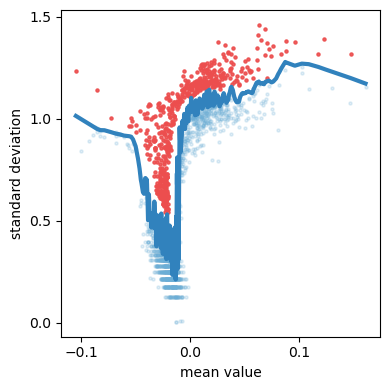

In [36]:
st.select_variable_genes(adata,loess_frac=0.01,percentile=80)

In [ ]:
# # 'var_genes' vs 'all' : use top % or all genes from .var ; if using all make sure the adata is subsetted to only the highly variable genes
# # n_components = Number of branches present in your biological differentation (min 2 dimensions for plotting, 3 would make it 3D)
# # method = 'se' or 'mlle' standard LLE or modified LLE
st.dimension_reduction(adata,method='se',feature='var_genes',n_components=2,n_neighbors=30,n_jobs=64) # using the same knn as diffusion maps (default is 30)

feature all is being used ...
64 cpus are being used ...


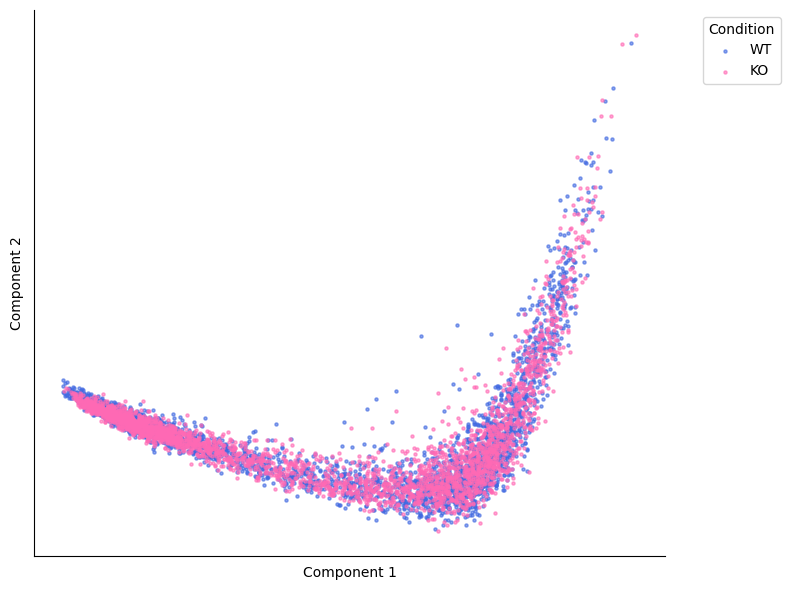

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Color dictionary for conditions
condition_color_dict = {
    'WT': '#4169E1',     # royal blue
    'KO': '#FF69B4'      # hot pink
}

# Ensure condition is categorical
adata.obs['condition'] = pd.Categorical(
    adata.obs['condition'],
    categories=['WT', 'KO'],
    ordered=True
)

# Extract coordinates from the 'X_dr'/'X_mlle' slot 
coords = adata.obsm['X_dr']  # or 'X_mlle'

# Extract the labels for coloring
labels = adata.obs['condition']

# Get unique labels and their corresponding colors
unique_labels = labels.cat.categories  # Use .cat.categories to maintain order
color_list = [condition_color_dict[label] for label in unique_labels]

# Plotting with colors based on condition
plt.figure(figsize=(8, 6))
for label, color in zip(unique_labels, color_list):
    idx = labels == label
    plt.scatter(coords[idx, 0], coords[idx, 1], c=color, label=label, s=5, alpha=0.6)

# Remove ticks
plt.xticks([])
plt.yticks([])

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.title('')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# plt.savefig('/your/path/condition_plot.pdf', 
#             bbox_inches='tight',
#             dpi=300,
#             format='pdf')

plt.show()